# <u>**Trabajo Práctico N°2: FFT y Métricas de Enfoque**</u>

- Visión por Computadora **[TA146]** - 1°C 2026

- Chechko, Víctor Nicolás **[110.901]**

- [Enunciado](https://github.com/maximdorogov/fundamentos-de-vision-fiuba/blob/main/trabajos_practicos/tp2/enunciado_tp2.png).

In [1]:
# Imports.

import os
import requests
import numpy as np
import cv2

from matplotlib import pyplot as plt

In [2]:
# Carga del video a utilizar.

video_url = 'https://raw.githubusercontent.com/maximdorogov/fundamentos-de-vision-fiuba/main/trabajos_practicos/tp2/focus_video.mov'

video_filename = 'focus_video.mov'

# Lo obtenemos desde el repositorio por si no está.

if not os.path.exists(video_filename):
    video = requests.get(video_url)

    with open(video_filename, "wb") as file:
        file.write(video.content)

In [3]:
# Función que transforma una imagen automáticamente de BGR a RGB y la muestra con pyplot.

def plt_imshow(img, title=None):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if title != None:
        plt.title(title)
    plt.axis('off')
    plt.show()

## **1.** Métrica 1 (mediante FFT)

A la hora de poder detectar mediante un algoritmo qué tan enfocada está una imagen, resulta útil analizarla en el dominio de la frecuencia tras haber computado su transformada de Fourier con una FFT, pues sabemos que el enfoque está directamente relacionado con el contenido espectral, en tanto que una imagen más enfocada tendrá cambios o bordes más bruscos, asociados a frecuencias más altas, presentando por lo tanto un espectro en general más homogéneo y más rico en estas altas frecuencias.

<br>

En este apartado, se implementa una función que recibe una imagen en espacio monocromático y devuelve un valor asociado al enfoque de acuerdo a la métrica propuesta en el documento [Image Sharpness Measure for Blurred Images in Frequency Domain](https://www.sciencedirect.com/science/article/pii/S1877705813016007).

<br>

La misma aplica la FFT a la imagen, halla el valor máximo que posee cualquier frecuencia, define un umbral que equivale a dicho valor máximo dividido entre $1000$, y cuenta la cantidad de píxeles que superan dicho umbral, normalizando luego según el tamaño de la imagen.

### Implementación

In [4]:
# La función recibe la imagen (asumiendo que ya está en blanco y negro)
# y devuelve el valor de la métrica obtenida.

# Se podrían aplicar muchos pasos inline, pero así se explicitan los que
# se mencionan en el documento.

def img_sharpness(img):

    # Paso 1 - Computar la FFT de la imagen.
    F = np.fft.fft2(img)

    # Paso 2 - Shift de la FFT al centro.
    FC= np.fft.fftshift(F)

    # Paso 3 - Cálculo del valor absoluto de la FFT shifteada.
    AF = np.abs(FC)

    # Paso 4 - Cálculo del máximo valor de cualquier componente en la FFT.
    M = np.max(AF)

    # Paso 5 - Cálculo de la cantidad de píxeles que superan el umbral (máximo anterior sobre 1000).
    thres = M / 1000.0
    TH = np.sum(AF > thres)

    # Paso 6 - Obtención final de la métrica.
    M, N = img.shape
    FM = TH / (M * N)

    return FM

A continuación, contamos los frames totales que posee el video `focus_video.mov` y medimos el enfoque en algún frame intermedio.

Total de frames del video: 171



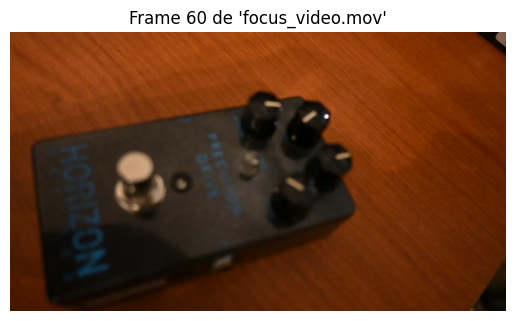


Valor de la métrica para el frame 60: 0.018299


In [5]:
# Probamos a aplicar el algoritmo a un frame aleatorio del video.

video_cap = cv2.VideoCapture(video_filename)

total_frames = int(video_cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Total de frames del video: {total_frames}\n")

frame_n = 60

video_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_n)

success, frame = video_cap.read()

if success:
    plt_imshow(frame, f"Frame {frame_n} de '{video_filename}'")
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    print(f"\nValor de la métrica para el frame {frame_n}: {img_sharpness(frame_gray):.6f}")

video_cap.release()

Visualicemos, para ejemplificar, la matriz que resulta luego de aplicar la FFT a dicho frame.

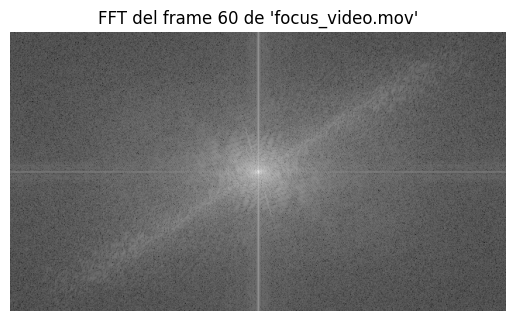

In [6]:
frame_gray_FFT = np.abs(np.fft.fftshift(np.fft.fft2(frame_gray)))

plt.imshow(20*np.log(frame_gray_FFT), cmap='gray')
plt.title(f"FFT del frame {frame_n} de '{video_filename}'")
plt.axis('off')
plt.show()

### Evaluación Sobre el Video

Utilizando la captura de video de `cv2`, recorremos todos los frames de `focus_video.mov` y calculamos la métrica, guardando los valores en un vector para luego poder hallar aquellos frames que la maximizan y minimizan.

In [7]:
video_cap = cv2.VideoCapture(video_filename)

f = 0 # Índice para los frames.
FM_vec = [] # Vector para almacenar los valores de la Focus Metric para cada frame.

while True:
    success, frame = video_cap.read()

    # Salir del bucle una vez que terminamos de leer todos los frames.
    if not success:
        break

    FM_vec.append(img_sharpness(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)))

    f += 1

video_cap.release()

f_min, f_max = np.argmin(FM_vec), np.argmax(FM_vec)

print("Proceso terminado.\n")
print(f"Frame de máximo enfoque: {f_max}")
print(f"Frame de mínimo enfoque: {f_min}")

Proceso terminado.

Frame de máximo enfoque: 109
Frame de mínimo enfoque: 15


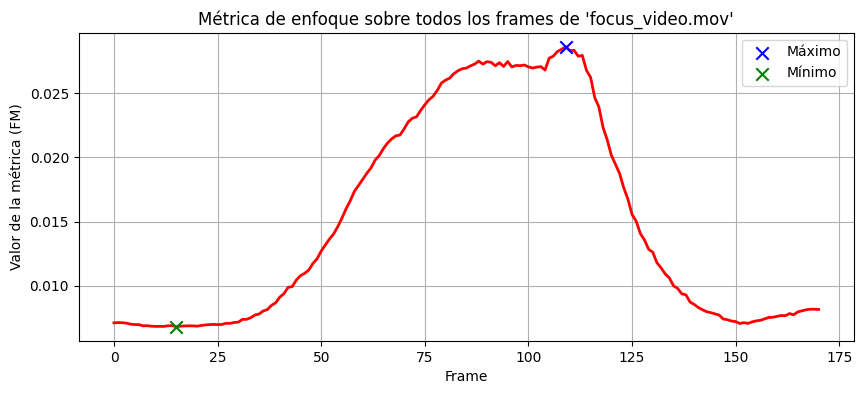

In [8]:
# Mostramos el plot de la métrica sobre todos los frames del video.

plt.figure(figsize=(10,4))
plt.plot(FM_vec, 'r', linewidth=2, zorder=2)
plt.scatter(f_max, np.max(FM_vec), marker='x', color='blue', s=80, linewidth=1.5, zorder=3, label='Máximo')
plt.scatter(f_min, np.min(FM_vec), marker='x', color='green', s=80, linewidth=1.5, zorder=3, label='Mínimo')

plt.xlabel("Frame")
plt.ylabel("Valor de la métrica (FM)")
plt.title(f"Métrica de enfoque sobre todos los frames de '{video_filename}'")
plt.grid(True)
plt.legend()
plt.show()

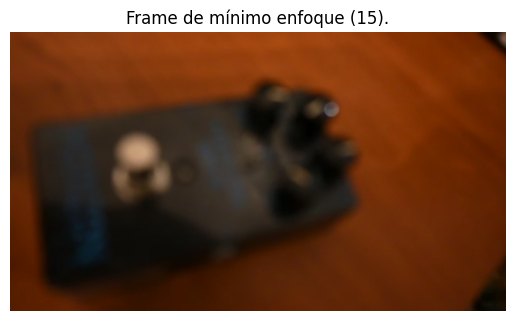

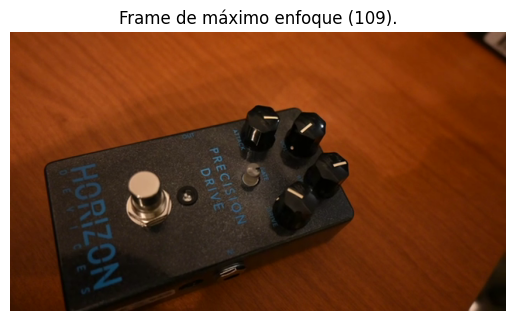

In [9]:
# Mostramos el frame más enfocado y el más desenfocado según la métrica utilizada.

video_cap = cv2.VideoCapture(video_filename)

for i, f in enumerate([f_min, f_max]):
    type_str = "mínimo" if i == 0 else "máximo"

    video_cap.set(cv2.CAP_PROP_POS_FRAMES, f)
    success, frame = video_cap.read()

    if success:
        plt_imshow(frame, f"Frame de {type_str} enfoque ({f}).")

    print("")

video_cap.release()

### ROI Sobre el Centro

Repetimos el procedimiento anterior pero, en lugar de calcular la métrica sobre cada frame completo, vamos a recortar sobre una región de interés (ROI) en el centro, ocupando un área de entre el $5\ \%$ y el $10\ \%$ del área de las dimensiones del frame original.

In [10]:
video_cap = cv2.VideoCapture(video_filename)

f = 0 # Índice para los frames.
FM_vec = [] # Vector para almacenar los valores de la Focus Metric para cada frame.

A_percent = 8 # Área de la ROI = 8% del área total del frame.

while True:
    success, frame = video_cap.read()

    # Salir del bucle una vez que terminamos de leer todos los frames.
    if not success:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Calculamos las dimensiones y la relación de aspecto, para luego determinar
    # la nueva longitud (new_w) que logra el área deseada.
    h, w = frame_gray.shape
    rel = w / h
    A = A_percent / 100 * w * h
    new_w = np.sqrt(A * rel)
    new_h = new_w / rel

    # ROI en el centro.
    y1, y2 = int(np.round(h / 2 - new_h / 2)), int(np.round(h / 2 + new_h / 2))
    x1, x2 = int(np.round(w / 2 - new_w / 2)), int(np.round(w / 2 + new_w / 2))

    frame_roi = frame_gray[y1:y2, x1:x2]

    FM_vec.append(img_sharpness(frame_roi))

    f += 1

video_cap.release()

FM_vec_roi = FM_vec # A utilizar después en la comparación entre FM y VL.

f_min, f_max = np.argmin(FM_vec), np.argmax(FM_vec)

print("Proceso terminado.\n")
print(f"Frame de máximo enfoque: {f_max}")
print(f"Frame de mínimo enfoque: {f_min}")

Proceso terminado.

Frame de máximo enfoque: 111
Frame de mínimo enfoque: 13


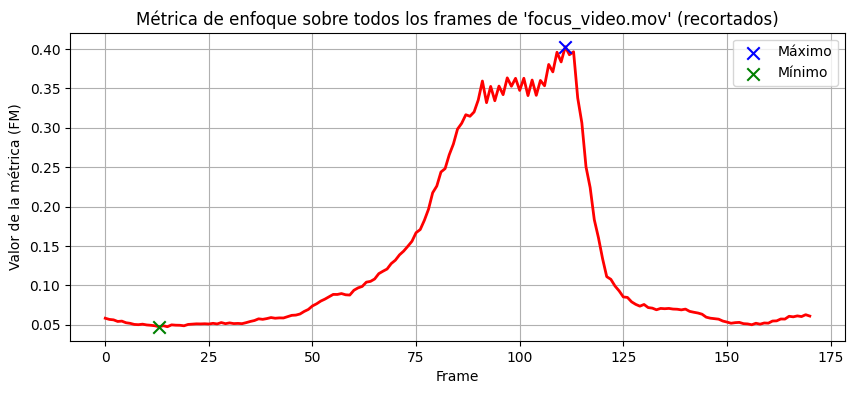

In [11]:
# Mostramos el plot de la métrica sobre todos los frames del video (recortados).

plt.figure(figsize=(10,4))
plt.plot(FM_vec, 'r', linewidth=2, zorder=2)
plt.scatter(f_max, np.max(FM_vec), color='blue', marker='x', s=80, linewidth=1.5, zorder=3, label='Máximo')
plt.scatter(f_min, np.min(FM_vec), color='green', marker='x', s=80, linewidth=1.5, zorder=3, label='Mínimo')

plt.xlabel("Frame")
plt.ylabel("Valor de la métrica (FM)")
plt.title(f"Métrica de enfoque sobre todos los frames de '{video_filename}' (recortados)")
plt.grid(True)
plt.legend()
plt.show()

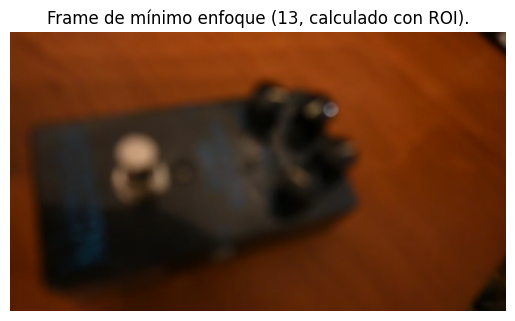

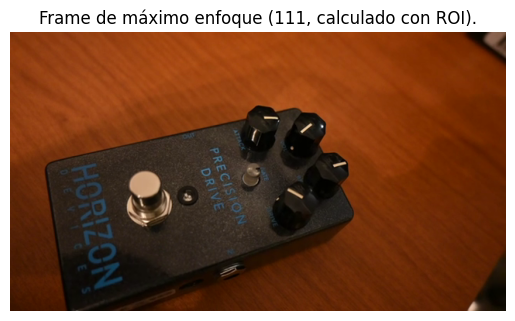

In [12]:
# Mostramos el frame más enfocado y el más desenfocado según la métrica utilizada.

video_cap = cv2.VideoCapture(video_filename)

for i, f in enumerate([f_min, f_max]):
    type_str = "mínimo" if i == 0 else "máximo"

    video_cap.set(cv2.CAP_PROP_POS_FRAMES, f)
    success, frame = video_cap.read()

    if success:
        plt_imshow(frame, f"Frame de {type_str} enfoque ({f}, calculado con ROI).")

    print("")

video_cap.release()

Como vemos, los resultados no varían significativamente. Al utilizar una ROI en el centro de la imagen con un área del $8\ \%$ del área del frame original, el frame de mínimo enfoque pasó de ser el $109$ a ser el $111$; y el de mínimo enfoque pasó de ser el $15$ a ser el $13$. Esperamos que al variar el porcentaje del área, dichos números de frame puedan cambiar un poco pero se mantengan en torno a estos valores.

### Métrica Sobre una Grilla

La idea ahora es dividir cada frame en una grilla de sub-imágenes de distintos tamaños (se probarán 4 tamaños de grilla distintos), de forma que se obtendrá un valor local de enfoque distinto para cada celda, en lugar de uno único global. Esto nos permite medir el enfoque sobre distintas partes de la imagen y ver si varía significativamente entre una y otra.

In [13]:
# La función recibe el video a analizar, la cantidad de filas (N) y columnas (M) de la grilla,
# y la métrica a utilizar (contemplando que en el apartado siguiente, la vamos a cambiar),
# devolviendo un vector de matrices de enfoque de tamaño N x M para cada frame del video.

def grid_img_sharpness(video, N, M, measure):
    video_cap = cv2.VideoCapture(video)

    f = 0 # Índice para los frames.
    FM_matrix_vec = [] # Vector para almacenar las matrices de enfoque de cada frame.

    while True:
        success, frame = video_cap.read()

        # Salir del bucle una vez que terminamos de leer todos los frames.
        if not success:
            break

        FM_matrix = np.zeros((N, M))

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        h, w = frame_gray.shape

        h_block = h // N
        w_block = w // M

        for i in range(N):
            for j in range(M):
                frame_cell = frame_gray[i*h_block:(i+1)*h_block, j*w_block:(j+1)*w_block]

                FM_matrix[i, j] = measure(frame_cell)

        FM_matrix_vec.append(FM_matrix)

        f += 1

    video_cap.release()

    return FM_matrix_vec

Los tamaños de grilla probados en la implementación original son $[(3\times3), (7\times5), (5\times7), (9\times9)]$.

In [14]:
# (este bloque puede tardar varios segundos en terminar de ejecutarse).

grid_sizes = [(3, 3), (7, 5), (5, 7), (9, 9)]

FM_matrices_by_grid = []

for N, M in grid_sizes:
    FM_matrices_by_grid.append(grid_img_sharpness(video_filename, N, M, img_sharpness))

Tenemos varias formas de visualizar los resultados obtenidos. Al haber cuatro variables, siendo éstas el número de frame, la posición vertical y horizontal en la grilla, y el valor de enfoque, podemos colapsar la grilla y reducir el número de variables a tres, visualizando cada resultado como un espectrograma.

<br>

Esto es lo que se hace a continuación, donde el eje horizontal representa el número de frame, el eje vertical representa el número de elemento dentro de la grilla (9 elementos para $(3\times3)$, 35 elementos para $(7\times5)$, etc.).

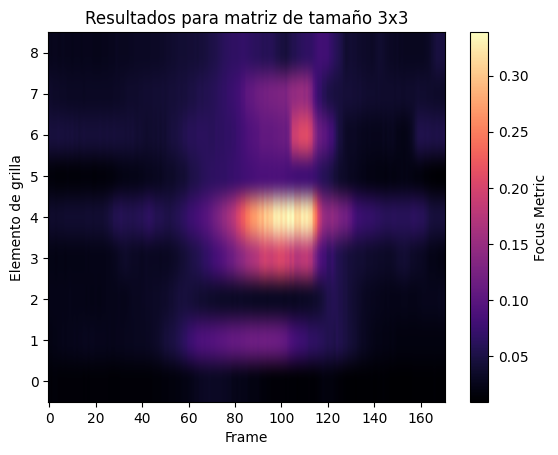

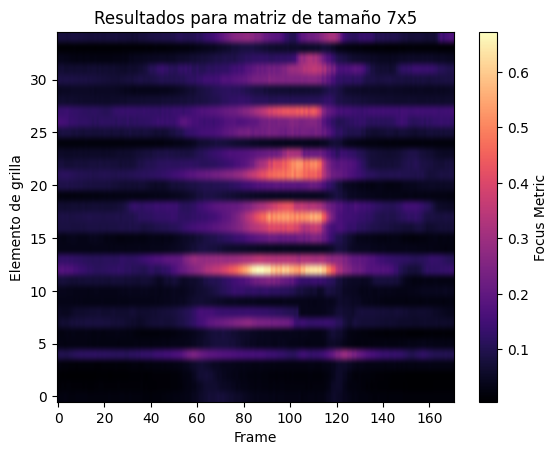

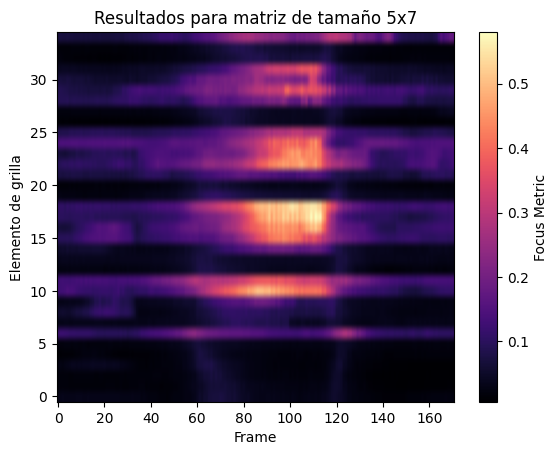

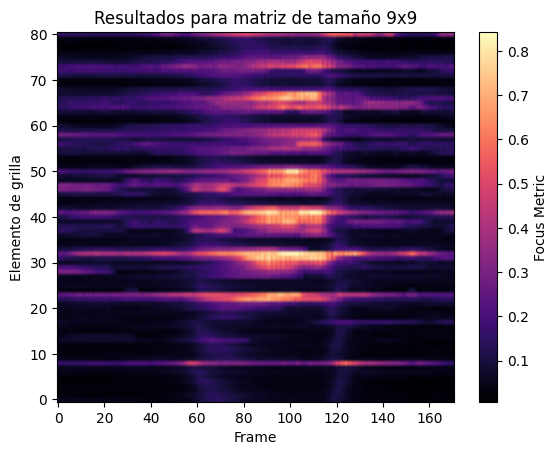

In [15]:
for i, FM_matrix_vec in enumerate(FM_matrices_by_grid):
    spectrogram_matrix = np.array([FM_matrix.flatten() for FM_matrix in FM_matrix_vec]).T

    plt.imshow(spectrogram_matrix, aspect='auto', origin='lower', cmap='magma')
    plt.xlabel("Frame")
    plt.ylabel("Elemento de grilla")
    plt.colorbar(label="Focus Metric")
    plt.title(f"Resultados para matriz de tamaño {grid_sizes[i][0]}x{grid_sizes[i][1]}")
    plt.show()

    print("")

Se observa principalmente un aumento general en el enfoque a medida que nos acercamos a los frames en el intervalo $[80, 120]$, con un valor obtenido mayor en los elementos centrales de la imagen.

<br>

Otra forma de visualización es escoger un frame determinado, y analizar la métrica para cada elemento $(n, m)$ de la grilla. Hagamos esto para el frame $111$ y la grilla de $9\times9$:

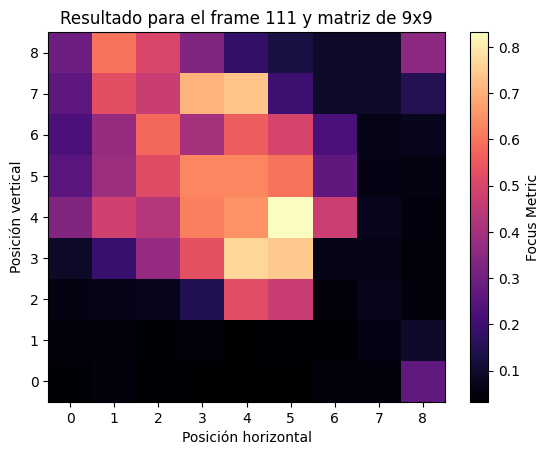

In [16]:
grid_size_n = 3 # 9x9
frame_n = 111

max_focus_frame_matrix = FM_matrices_by_grid[grid_size_n][frame_n]

plt.imshow(max_focus_frame_matrix, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Posición horizontal")
plt.ylabel("Posición vertical")
plt.colorbar(label="Focus Metric")
plt.title(f"Resultado para el frame {frame_n} y matriz de {grid_sizes[grid_size_n][0]}x{grid_sizes[grid_size_n][1]}")
plt.show()

Se confirma la conclusión anterior, ya que ahora podemos ver directamente que el enfoque se maximiza sobre el elemento $(5, 4)$ de la grilla, cerca del centro de la imagen.

## **2.** Métrica 2 (mediante el Laplaciano)

En este segundo apartado, vamos a repetir todos los pasos anteriores cambiando la métrica a utilizar.

<br>

Dado que el enunciado del trabajo pide escoger una única alternativa, se decidió optar por la de la varianza del Laplaciano (catalogada como **LAP4** en [Analysis of Focus Measure Operators in Shape-From-Focus](https://www.researchgate.net/publication/234073157_Analysis_of_focus_measure_operators_in_shape-from-focus)), ya que posee un principio de operación diferente al utilizado anteriormente (espacial en lugar de espectral), y resulta simple y útil para realizar una comparación entre ambos métodos.

### Implementación

El Laplaciano de una imagen está asociado al cambio en el gradiante de la misma. En un sentido físico, puede compararse con la magnitud de la "aceleración" de los valores de intensidad, por lo que responde fuerte cuando hay cambios bruscos (bordes) y responde poco en regiones planas.

<br>

Se determina como la suma de los cuadrados de las componentes de gradiente para cada píxel:

<br>

$$
\nabla^2I(x,y)=\frac{\partial^2I(x,y)}{\partial x}+\frac{\partial^2I(x,y)}{\partial y}
$$

<br>

Por lo tanto, a diferencia del gradiente, es un escalar y no brinda información sobre la dirección del cambio, sino solo de su intensidad o fuerza. En el código, se puede hallar utilizando `cv2.Laplacian(image, cv2.CV_64F)`, donde `cv2.CV_64F` indica que los valores devueltos se deben guardar en variables del tipo `float64`.

<br>

En una imagen más enfocada, esperamos un Laplaciano fuerte en las transiciones fondo-objeto u objeto-objeto, mientras que será débil en las zonas planas; en una imagen desenfocada, el Laplaciano será más uniforme a lo largo de todos los píxeles. Es por ello que la métrica propuesta se basa en computar la varianza del Laplaciano:

<br>

$$
VL=\text{Var}[\nabla^2I(x,y)]
$$

<br>

Resulta así computacionalmente más simple que la métrica anterior con la FFT, trabajando con un principio distinto pero conceptualmente análogo. En este caso, no es necesario normalizar según el tamaño de la imagen ya que la operación de varianza ya incorpora un promedio sobre la cantidad de píxeles analizados.

In [17]:
def variance_of_laplacian(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    return np.var(laplacian)

Para ejemplificar, podemos visualizar la matriz que resulta luego de aplicar el Laplaciano a un frame arbitrario del video.

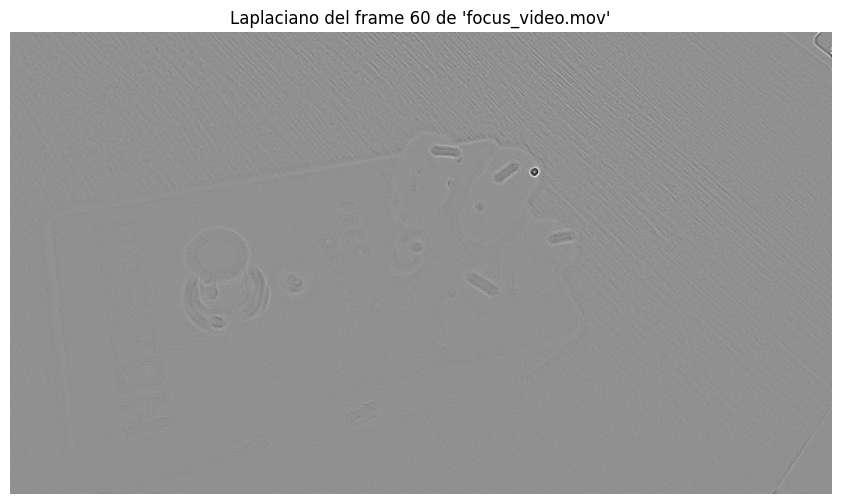

In [18]:
# Laplaciano de un frame arbitrario del video.

video_cap = cv2.VideoCapture(video_filename)

frame_n = 60

video_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_n)

success, frame = video_cap.read()

if success:
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_gray_laplacian = cv2.Laplacian(frame_gray, cv2.CV_64F)
    plt.figure(figsize=(12,6))
    plt.imshow(20*frame_gray_laplacian, cmap='gray')
    plt.title(f"Laplaciano del frame {frame_n} de '{video_filename}'")
    plt.axis('off')
    plt.show()

video_cap.release()

Lo que sigue a continuación es el mismo procedimiento ya realizado y explicado en el apartado anterior, por lo que sólo se muestran los resultados y se hace una comparación de los mismos al final.

### Evaluación Sobre el Video

In [19]:
video_cap = cv2.VideoCapture(video_filename)

f = 0 # Índice para los frames.
VL_vec = [] # Vector para almacenar los valores de la VL para cada frame.

while True:
    success, frame = video_cap.read()

    # Salir del bucle una vez que terminamos de leer todos los frames.
    if not success:
        break

    VL_vec.append(variance_of_laplacian(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)))

    f += 1

video_cap.release()

f_min, f_max = np.argmin(VL_vec), np.argmax(VL_vec)

print("Proceso terminado.\n")
print(f"Frame de máximo enfoque: {f_max}")
print(f"Frame de mínimo enfoque: {f_min}")

Proceso terminado.

Frame de máximo enfoque: 111
Frame de mínimo enfoque: 1


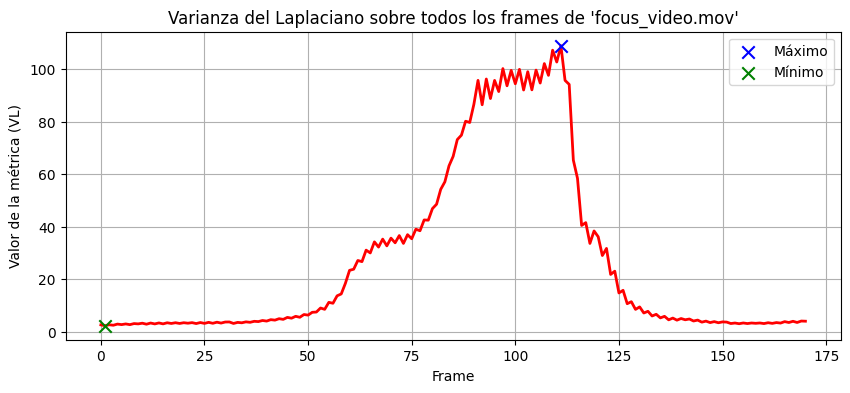

In [20]:
# Mostramos el plot de la métrica sobre todos los frames del video.

plt.figure(figsize=(10,4))
plt.plot(VL_vec, 'r', linewidth=2, zorder=2)
plt.scatter(f_max, np.max(VL_vec), color='blue', marker='x', s=80, linewidth=1.5, zorder=3, label='Máximo')
plt.scatter(f_min, np.min(VL_vec), color='green', marker='x', s=80, linewidth=1.5, zorder=3, label='Mínimo')

plt.xlabel("Frame")
plt.ylabel("Valor de la métrica (VL)")
plt.title(f"Varianza del Laplaciano sobre todos los frames de '{video_filename}'")
plt.grid(True)
plt.legend()
plt.show()

### ROI Sobre el Centro

In [21]:
video_cap = cv2.VideoCapture(video_filename)

f = 0 # Índice para los frames.
VL_vec = [] # Vector para almacenar los valores de la VL para cada frame.

A_percent = 8 # Área de la ROI = 8% del área total del frame.

while True:
    success, frame = video_cap.read()

    # Salir del bucle una vez que terminamos de leer todos los frames.
    if not success:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Calculamos las dimensiones y la relación de aspecto, para luego determinar
    # la nueva longitud (new_w) que logra el área deseada.
    h, w = frame_gray.shape
    rel = w / h
    A = A_percent / 100 * w * h
    new_w = np.sqrt(A * rel)
    new_h = new_w / rel

    # ROI en el centro.
    y1, y2 = int(np.round(h / 2 - new_h / 2)), int(np.round(h / 2 + new_h / 2))
    x1, x2 = int(np.round(w / 2 - new_w / 2)), int(np.round(w / 2 + new_w / 2))

    frame_roi = frame_gray[y1:y2, x1:x2]

    VL_vec.append(variance_of_laplacian(frame_roi))

    f += 1

video_cap.release()

VL_vec_roi = VL_vec # A utilizar después en la comparación entre FM y VL.

f_min, f_max = np.argmin(VL_vec), np.argmax(VL_vec)

print("Proceso terminado.\n")
print(f"Frame de máximo enfoque: {f_max}")
print(f"Frame de mínimo enfoque: {f_min}")

Proceso terminado.

Frame de máximo enfoque: 111
Frame de mínimo enfoque: 3


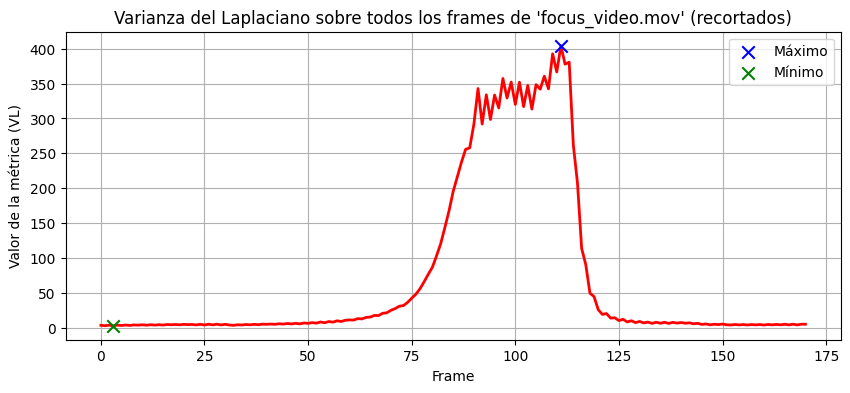

In [22]:
# Mostramos el plot de la métrica sobre todos los frames del video (recortados).

plt.figure(figsize=(10,4))
plt.plot(VL_vec, 'r', linewidth=2, zorder=2)
plt.scatter(f_max, np.max(VL_vec), color='blue', marker='x', s=80, linewidth=1.5, zorder=3, label='Máximo')
plt.scatter(f_min, np.min(VL_vec), color='green', marker='x', s=80, linewidth=1.5, zorder=3, label='Mínimo')

plt.xlabel("Frame")
plt.ylabel("Valor de la métrica (VL)")
plt.title(f"Varianza del Laplaciano sobre todos los frames de '{video_filename}' (recortados)")
plt.grid(True)
plt.legend()
plt.show()

### Métrica Sobre una Grilla

In [23]:
grid_sizes = [(3, 3), (7, 5), (5, 7), (9, 9)]

VL_matrices_by_grid = []

for N, M in grid_sizes:
    VL_matrices_by_grid.append(grid_img_sharpness(video_filename, N, M, variance_of_laplacian))

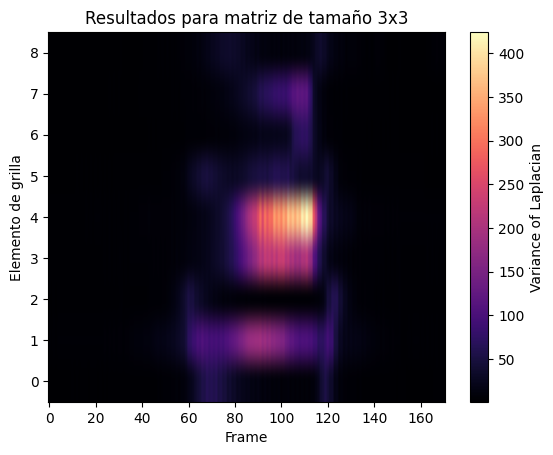

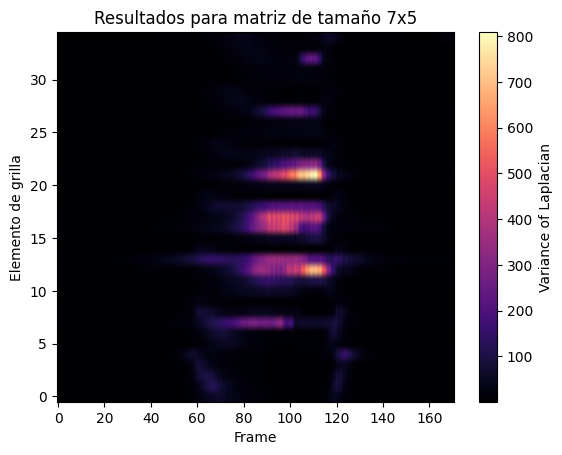

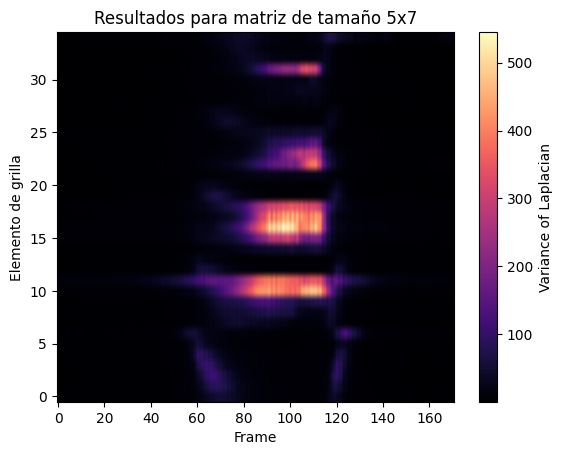

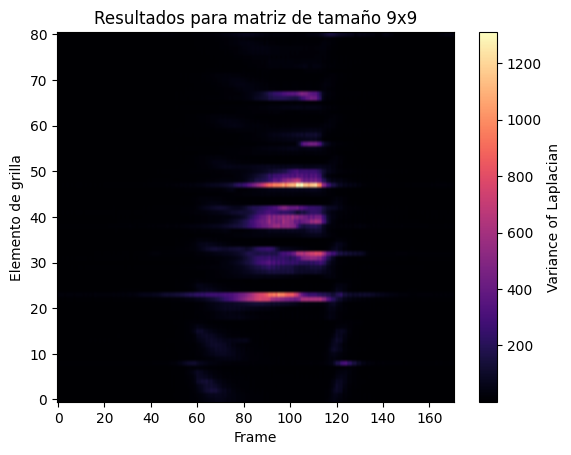

In [24]:
for i, VL_matrix_vec in enumerate(VL_matrices_by_grid):
    spectrogram_matrix = np.array([VL_matrix.flatten() for VL_matrix in VL_matrix_vec]).T

    plt.imshow(spectrogram_matrix, aspect='auto', origin='lower', cmap='magma')
    plt.xlabel("Frame")
    plt.ylabel("Elemento de grilla")
    plt.colorbar(label="Variance of Laplacian")
    plt.title(f"Resultados para matriz de tamaño {grid_sizes[i][0]}x{grid_sizes[i][1]}")
    plt.show()

    print("")

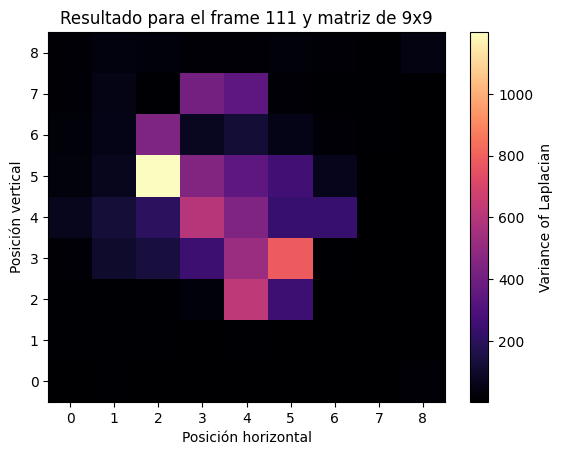

In [25]:
grid_size_n = 3 # 9x9
frame_n = 111

max_focus_frame_matrix = VL_matrices_by_grid[grid_size_n][frame_n]

plt.imshow(max_focus_frame_matrix, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Posición horizontal")
plt.ylabel("Posición vertical")
plt.colorbar(label="Variance of Laplacian")
plt.title(f"Resultado para el frame {frame_n} y matriz de {grid_sizes[grid_size_n][0]}x{grid_sizes[grid_size_n][1]}")
plt.show()

Como se esperaba, la varianza del Laplaciano también aumenta notablemente para los frames en el intervalo $[80, 120]$, aunque no siempre presenta su máximo en el centro de la grilla. Como vemos en el epectrograma inmediatamente encima de este párrafo, el máximo se halla en el elemento $(2, 5)$.

### Comparación y Conclusiones

Se muestra una comparación entre las curvas de evolución obtenidas para ambas métricas. La comparación es cualitativa en tanto que, como las dos devuelven valores en órdenes de magnitud muy distintos, se optó por escalar la curva FM para que coincida aproximadamente con la curva VL.

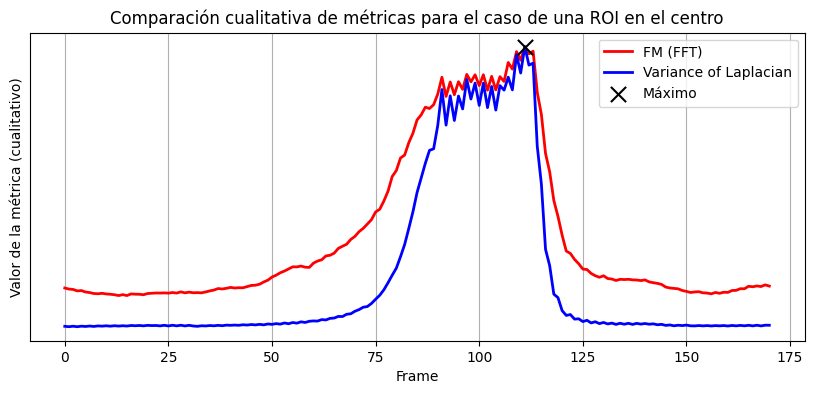

In [26]:
# Comparamos la evolución de la métrica FM con la VL, en el caso de utilizar una ROI en el centro de cada frame.

plt.figure(figsize=(10,4))
plt.plot(np.array(FM_vec_roi) * np.max(VL_vec_roi) / np.max(FM_vec_roi), 'r', linewidth=2, label="FM (FFT)")
plt.plot(VL_vec_roi, 'b', linewidth=2, label="Variance of Laplacian")
plt.scatter(f_max, np.max(VL_vec_roi), color='black', marker='x', s=120, linewidth=1.5, zorder=3, label='Máximo')

plt.xlabel("Frame")
plt.ylabel("Valor de la métrica (cualitativo)")
plt.title(f"Comparación cualitativa de métricas para el caso de una ROI en el centro")
plt.yticks([])
plt.grid(True)
plt.legend()
plt.show()

A partir de los resultados obtenidos, puede concluirse que ambas métricas resultan adecuadas para la detección de enfoque en secuencias de video.

<br>

Sorpresivamente, al restringir el análisis a una ROI en el centro que ocupa el $8\ \%$ del área de cada frame original, las dos coinciden en identificar el frame de máximo enfoque como el frame $111$. Además, ambas curvas presentan una evolución temporal similar, lo que sugiere que las dos métricas capturan consistentemente las variaciones de nitidez presentes en la secuencia.

<br>

Se puede notar a su vez que la varianza del Laplaciano exhibe transiciones o picos más abruptos, mientras que la métrica basada en la FFT presenta un comportamiento más suave y gradual. Esto resulta consistente con la naturaleza de cada operador: la FFT mide contenido frecuencial global de la imagen, mientras que el Laplaciano enfatiza variaciones locales de intensidad y bordes.